In [4]:
import pandas as pd

file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"
df = pd.read_csv(file_path)
print(df.head())

     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [5]:
df.isnull().sum()

model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             3
mpg             0
engineSize      0
price           0
dtype: int64

In [6]:
# df is your DataFrame

# 1. Identify columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()

# 2. Replace missing values with the column mean
means = df[cols_with_missing].mean()
df[cols_with_missing] = df[cols_with_missing].fillna(means)

# 3. Delete duplicate rows
df.drop_duplicates(inplace=True)

In [7]:
target_col = "price"
encode = pd.get_dummies(df, columns=['model','transmission','fuelType'])
df_x = df[['year','mileage','tax','mpg','engineSize','price']]
corr = encode.corr().abs()
top5 = corr[target_col].drop(target_col).sort_values(ascending=False).head(10)
print(top5)

year                   0.635715
mileage                0.530483
engineSize             0.411451
tax                    0.405970
mpg                    0.346263
model_ Fiesta          0.333063
model_ Kuga            0.281926
model_ Mustang         0.267520
transmission_Manual    0.258201
model_ Edge            0.237867
Name: price, dtype: float64


In [8]:
column = 'fuelType'  
counts = df[column].value_counts()
print(counts)

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

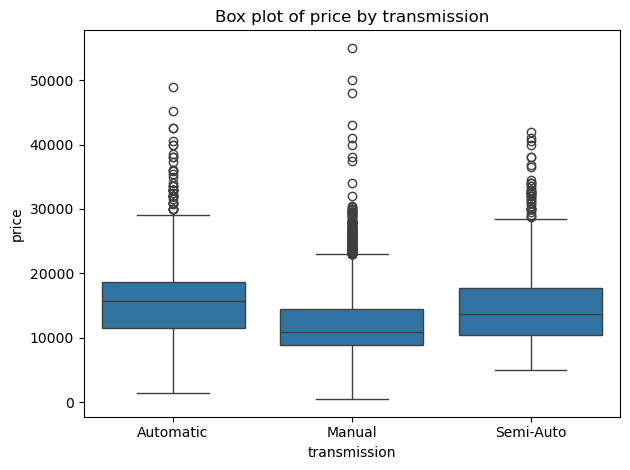

In [10]:
source_col = 'transmission'
target_col = 'price'

sns.boxplot(x=source_col, y=target_col, data=df)
plt.xlabel(source_col)
plt.ylabel(target_col)
plt.title(f'Box plot of {target_col} by {source_col}')
plt.tight_layout()
plt.show()

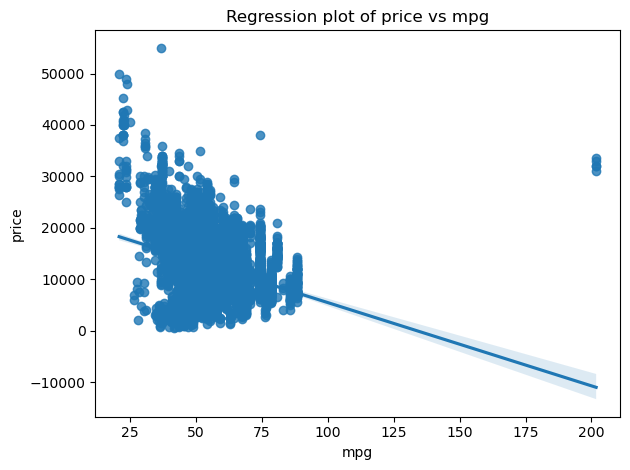

In [11]:
source_col = 'mpg'
target_col = 'price'

sns.regplot(x=source_col, y=target_col, data=df)
plt.xlabel(source_col)
plt.ylabel(target_col)
plt.title(f'Regression plot of {target_col} vs {source_col}')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

In [13]:
x_col = 'mpg'
y_col = 'price'


x = df[x_col].to_numpy()
y = df[y_col].to_numpy()

mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

mean_x = x.mean()
mean_y = y.mean()

slope = ((x - mean_x) * (y - mean_y)).sum() / ((x - mean_x) ** 2).sum()
intercept = mean_y - slope * mean_x

y_hat = intercept + slope * x
ss_res = ((y - y_hat) ** 2).sum()
ss_tot = ((y - mean_y) ** 2).sum()

r2 = 1 - ss_res / ss_tot
mse = ss_res / len(y)

print("Intercept:", intercept)
print("Slope:", slope)
print("R^2:", r2)
print("MSE:", mse)

Intercept: 21642.211603074804
Slope: -161.85229296989374
R^2: 0.11989802249624171
MSE: 19741690.809446193


In [14]:
y_col = 'price'
predictor_cols = ['year', 'mileage','tax','mpg','engineSize'] 

X = df[predictor_cols].to_numpy(dtype=float)
y = df[y_col].to_numpy(dtype=float)

mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X = X[mask]
y = y[mask]

X_design = np.column_stack([np.ones(X.shape[0]), X])

beta = np.linalg.lstsq(X_design, y, rcond=None)[0]

y_hat = X_design.dot(beta)
ss_res = ((y - y_hat) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
mse = ss_res / len(y)

print("Intercept:", beta[0])
for i, col in enumerate(predictor_cols, start=1):
    print(f"Slope for {col}:", beta[i])
print("R^2:", r2)
print("MSE:", mse)

Intercept: -2441083.7768117455
Slope for year: 1215.8062570887416
Slope for mileage: -0.05824401840762167
Slope for tax: 0.7848837206777008
Slope for mpg: -81.17034016134711
Slope for engineSize: 5340.31546173591
R^2: 0.7265379654547004
MSE: 6134065.224381736


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [16]:
X = df[predictor_cols].to_numpy(dtype=float)
y = df[y_col].to_numpy(dtype=float)

pipeline = Pipeline([
    ("scaler",  StandardScaler()),                          # Step 1: Standardise
    ("poly",    PolynomialFeatures(degree=2,                # Step 2: 2nd-degree
                                   include_bias=False)),    #         poly features
    ("model",   LinearRegression()),                        # Step 3: Linear model
])

pipeline.fit(X, y)

y_pred = pipeline.predict(X)
r2  = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("=" * 45)
print("         Model Evaluation Metrics")
print("=" * 45)
print(f"  R²  (coefficient of determination) : {r2:.4f}")
print(f"  MSE (mean squared error)            : {mse:.4f}")
print("=" * 45)

         Model Evaluation Metrics
  R²  (coefficient of determination) : 0.7667
  MSE (mean squared error)            : 5234038.0655


In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20 % held out for testing
    random_state=42     # reproducibility
)

ridge_model = Ridge(alpha=0.1)          # regularization parameter λ = 0.1
ridge_model.fit(X_train, y_train)       # fit on training data only

y_pred = ridge_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n" + "=" * 45)
print("       Ridge Regression — Test Metrics")
print("=" * 45)
print(f"  Regularization parameter (alpha) : 0.1")
print(f"  MSE (mean squared error)         : {mse:.4f}")
print(f"  R²  (coefficient of determination): {r2:.4f}")
print("=" * 45)


       Ridge Regression — Test Metrics
  Regularization parameter (alpha) : 0.1
  MSE (mean squared error)         : 6912725.8011
  R²  (coefficient of determination): 0.6917


In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)   # fit on train, then transform
X_test_poly  = poly.transform(X_test)        # transform test using same fit

In [21]:
ridge_poly = Ridge(alpha=0.1)
ridge_poly.fit(X_train_poly, y_train)        # fit on transformed training data

/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [22]:
y_pred_poly = ridge_poly.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly  = r2_score(y_test, y_pred_poly)

print("\n" + "=" * 50)
print("   Ridge Regression (Poly Features) — Test Metrics")
print("=" * 50)
print(f"  Regularization parameter (alpha)  : 0.1")
print(f"  Polynomial degree                 : 2")
print(f"  MSE (mean squared error)          : {mse_poly:.4f}")
print(f"  R²  (coefficient of determination): {r2_poly:.4f}")
print("=" * 50)


   Ridge Regression (Poly Features) — Test Metrics
  Regularization parameter (alpha)  : 0.1
  Polynomial degree                 : 2
  MSE (mean squared error)          : 7326174.8742
  R²  (coefficient of determination): 0.6733


In [23]:
ridge_plain = Ridge(alpha=0.1)
ridge_plain.fit(X_train, y_train)
y_pred_plain = ridge_plain.predict(X_test)

mse_plain = mean_squared_error(y_test, y_pred_plain)
r2_plain  = r2_score(y_test, y_pred_plain)

print("\n" + "=" * 50)
print("         Model Comparison (alpha = 0.1)")
print("=" * 50)
print(f"  {'Model':<30} {'MSE':>7}  {'R²':>7}")
print(f"  {'-'*44}")
print(f"  {'Ridge (original features)':<30} {mse_plain:>7.4f}  {r2_plain:>7.4f}")
print(f"  {'Ridge (poly degree-2 features)':<30} {mse_poly:>7.4f}  {r2_poly:>7.4f}")
print("=" * 50)


         Model Comparison (alpha = 0.1)
  Model                              MSE       R²
  --------------------------------------------
  Ridge (original features)      6912725.8011   0.6917
  Ridge (poly degree-2 features) 7326174.8742   0.6733


In [27]:
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}   #alpha values

ridge = Ridge()

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=4,                       # 4-fold cross validation
    scoring="neg_mean_squared_error",
    return_train_score=True,
    verbose=1)

grid_search.fit(X_train_poly, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)

print("=" * 60)
print("        Grid Search — 4-Fold Cross Validation Results")
print("=" * 60)
print(f"  {'Alpha':>8}  {'Mean CV MSE':>12}  {'Std CV MSE':>11}  {'Mean Train MSE':>14}")
print(f"  {'-'*56}")
for _, row in cv_results.iterrows():
    alpha       = row["param_alpha"]
    cv_mse      = -row["mean_test_score"]
    std_mse     = row["std_test_score"]
    train_mse   = -row["mean_train_score"]
    marker = "  ◄ best" if alpha == grid_search.best_params_["alpha"] else ""
    print(f"  {alpha:>8}  {cv_mse:>12.4f}  {std_mse:>11.4f}  {train_mse:>14.4f}{marker}")
print("=" * 60)



Fitting 4 folds for each of 5 candidates, totalling 20 fits
        Grid Search — 4-Fold Cross Validation Results
     Alpha   Mean CV MSE   Std CV MSE  Mean Train MSE
  --------------------------------------------------------
      0.01  5068885.6022  220119.7968    5015420.3643  ◄ best
       0.1  5159629.8412  222603.4770    5107185.1276
       1.0  5200144.6463  221655.4805    5149761.1839
      10.0  5208455.2175  218072.0262    5159985.6021
     100.0  5218900.1911  211958.7770    5174162.8805


/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.0567e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.98143e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.10209e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.85743e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.9414e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/o

In [28]:
best_alpha = grid_search.best_params_["alpha"]
best_model = grid_search.best_estimator_

print(f"\n  ✔ Best alpha found : {best_alpha}")

y_pred_best = best_model.predict(X_test_poly)

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best  = r2_score(y_test, y_pred_best)

print("\n" + "=" * 60)
print(f"    Final Model Evaluation  (alpha = {best_alpha})")
print("=" * 60)
print(f"  MSE (mean squared error)           : {mse_best:.4f}")
print(f"  R²  (coefficient of determination) : {r2_best:.4f}")
print("=" * 60)

print("\n" + "=" * 60)
print("     Test-Set Performance Across All Alpha Values")
print("=" * 60)
print(f"  {'Alpha':>8}  {'Test MSE':>10}  {'Test R²':>10}")
print(f"  {'-'*34}")
for alpha in param_grid["alpha"]:
    model = Ridge(alpha=alpha).fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    marker = "  ◄ best" if alpha == best_alpha else ""
    print(f"  {alpha:>8}  {mse:>10.4f}  {r2:>10.4f}{marker}")
print("=" * 60)


  ✔ Best alpha found : 0.01

    Final Model Evaluation  (alpha = 0.01)
  MSE (mean squared error)           : 13840985.8046
  R²  (coefficient of determination) : 0.3827

     Test-Set Performance Across All Alpha Values
     Alpha    Test MSE     Test R²
  ----------------------------------
      0.01  13840985.8046      0.3827  ◄ best
       0.1  7326174.8742      0.6733
         1  6243524.4539      0.7216
        10  6105872.8274      0.7277
       100  6019439.8628      0.7316


/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.27922e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16298e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.0694e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.13182e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
